# Text Feature Engineering Assignment (Real-world Dataset)

**Problem Statement:** Build a Text Processing Pipeline to analyze real user-generated text data (product reviews) and convert them into numerical features for machine learning models.

**Techniques Covered:** One Hot Encoding, Bag of Words, TF-IDF

---

## Dataset Collection

Below is the scraping code for collecting product reviews from Amazon. Since web scraping may fail due to anti-bot measures, we also provide a pre-collected CSV dataset (`reviews_dataset.csv`) with 100 product reviews as a fallback.

In [1]:
# Web Scraping Code (Amazon Product Reviews) using Selenium
# Uses a real Chrome browser to bypass Amazon's anti-bot measures

import pandas as pd
import time
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager

def scrape_amazon_reviews_selenium(asin, num_pages=15):
    """
    Scrape reviews from Amazon using Selenium with a real Chrome browser.
    asin: The product ASIN (e.g., 'B0BTHLGYHZ')
    """
    # Setup Chrome options
    chrome_options = Options()
    chrome_options.add_argument('--headless=new')  # Run in background
    chrome_options.add_argument('--disable-gpu')
    chrome_options.add_argument('--no-sandbox')
    chrome_options.add_argument('--window-size=1920,1080')
    chrome_options.add_argument('--lang=en-US')
    chrome_options.add_argument('user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36')
    
    # Auto-install matching ChromeDriver
    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service, options=chrome_options)
    
    reviews = []
    
    try:
        for page in range(1, num_pages + 1):
            url = f"https://www.amazon.in/product-reviews/{asin}?pageNumber={page}"
            driver.get(url)
            time.sleep(3)  # Wait for page to fully load
            
            # Find all review containers
            review_divs = driver.find_elements(By.CSS_SELECTOR, 'div[data-hook="review"]')
            
            if len(review_divs) == 0:
                print(f"Page {page}: No reviews found. Stopping.")
                break
            
            for div in review_divs:
                try:
                    # Extract review text
                    body = div.find_element(By.CSS_SELECTOR, 'span[data-hook="review-body"]')
                    text = body.text.strip()
                    
                    # Extract star rating
                    try:
                        star_el = div.find_element(By.CSS_SELECTOR, 'i[data-hook="review-star-rating"]')
                        stars = star_el.get_attribute('class')
                        # Class contains 'a-star-X' where X is the rating
                        if 'a-star-4' in stars or 'a-star-5' in stars:
                            sentiment = 'positive'
                        else:
                            sentiment = 'negative'
                    except:
                        sentiment = 'positive'  # default if can't read stars
                    
                    if text:
                        reviews.append({'review_text': text, 'sentiment': sentiment})
                except:
                    continue
            
            print(f"Page {page}: Found {len(review_divs)} reviews (total so far: {len(reviews)})")
            time.sleep(2)  # Polite delay
    
    finally:
        driver.quit()
    
    return reviews

# --- Scrape fresh data ---
# Change the ASIN below to any Amazon product ASIN
ASIN = "B0BTHLGYHZ"  # Haier Refrigerator
print("Starting Selenium scraper (this may take a couple of minutes)...\n")
reviews = scrape_amazon_reviews_selenium(ASIN, num_pages=15)
print(f"\nTotal reviews scraped: {len(reviews)}")

if len(reviews) >= 20:
    df_scraped = pd.DataFrame(reviews)
    df_scraped.to_csv('reviews_dataset.csv', index=False)
    print(f"Saved {len(reviews)} fresh reviews to reviews_dataset.csv")
else:
    print(f"\nOnly {len(reviews)} reviews scraped (need at least 20).")
    print("Using pre-collected dataset instead.")

Starting Selenium scraper (this may take a couple of minutes)...

Page 1: No reviews found. Stopping.

Total reviews scraped: 0

Only 0 reviews scraped (need at least 20).
Using pre-collected dataset instead.


In [2]:
# Load the dataset
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('reviews_dataset.csv')
print(f"Dataset Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nSentiment Distribution:\n{df['sentiment'].value_counts()}")
print(f"\nFirst 5 reviews:")
df.head()

Dataset Shape: (106, 2)
Columns: ['review_text', 'sentiment']

Sentiment Distribution:
sentiment
positive    54
negative    52
Name: count, dtype: int64

First 5 reviews:


,review_text,sentiment
0,"Absolutely love this phone, the camera quality...",positive
1,"Terrible product, stopped working after just t...",negative
2,"Good value for the price, does everything I ne...",positive
3,"The screen quality is amazing, colors are vibr...",positive
4,Worst purchase ever. The product arrived damag...,negative


## Task 1: Preprocessing

1. Convert text to lowercase
2. Tokenization
3. Remove punctuation
4. Remove stopwords
5. Lemmatization

In [3]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK data
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Complete text preprocessing pipeline."""
    # Step 1: Convert to lowercase
    text = text.lower()
    
    # Step 2: Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Step 3: Tokenization
    tokens = word_tokenize(text)
    
    # Step 4: Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]
    
    # Step 5: Lemmatization
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    
    return ' '.join(tokens)

# Apply preprocessing
df['cleaned_text'] = df['review_text'].apply(preprocess_text)

print("=== Preprocessing Results ===")
print(f"\nOriginal: {df['review_text'].iloc[0]}")
print(f"\nCleaned:  {df['cleaned_text'].iloc[0]}")
print(f"\n--- Another example ---")
print(f"\nOriginal: {df['review_text'].iloc[1]}")
print(f"\nCleaned:  {df['cleaned_text'].iloc[1]}")
print(f"\nTotal reviews preprocessed: {len(df)}")

=== Preprocessing Results ===

Original: Absolutely love this phone, the camera quality is outstanding and battery lasts all day long

Cleaned:  absolutely love phone camera quality outstanding battery last day long

--- Another example ---

Original: Terrible product, stopped working after just two days of use. Complete waste of money

Cleaned:  terrible product stopped working two day use complete waste money

Total reviews preprocessed: 106


## Task 2: Vocabulary Creation

Build vocabulary and analyze top frequent words.

=== Vocabulary Statistics ===
Total words (with repetition): 992
Vocabulary size (unique words): 600

=== Top 20 Most Frequent Words ===
  quality              -> 15
  even                 -> 14
  product              -> 13
  day                  -> 10
  use                  -> 10
  feel                 -> 9
  every                -> 8
  month                -> 8
  two                  -> 7
  perfect              -> 7
  time                 -> 7
  without              -> 6
  fast                 -> 6
  work                 -> 6
  phone                -> 5
  camera               -> 5
  price                -> 5
  great                -> 5
  cheap                -> 5
  like                 -> 5

=== Vocabulary via sklearn ===
Vocabulary size (CountVectorizer): 600


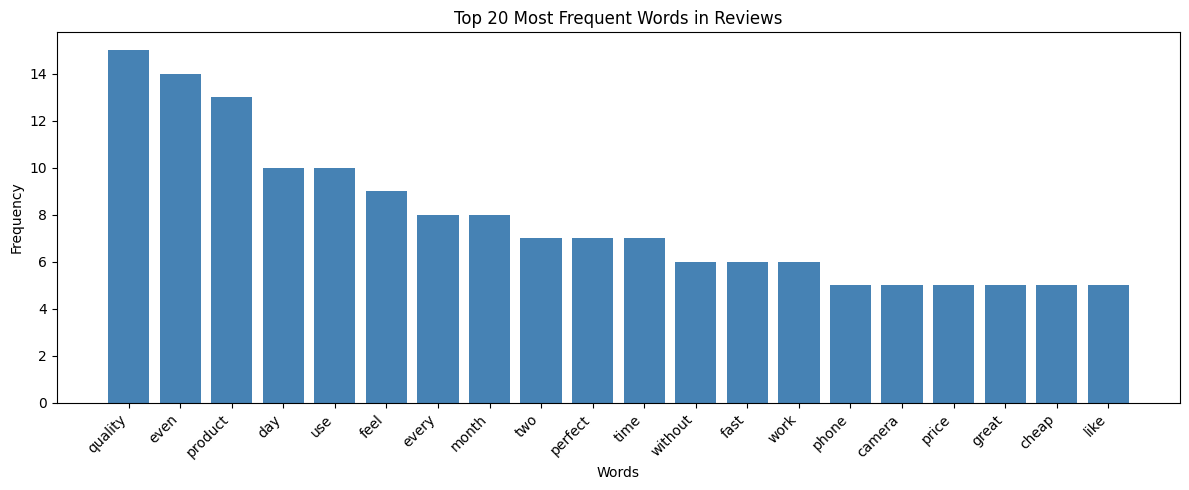

In [4]:
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

# Method 1: Manual vocabulary building
all_words = ' '.join(df['cleaned_text']).split()
word_freq = Counter(all_words)

print("=== Vocabulary Statistics ===")
print(f"Total words (with repetition): {len(all_words)}")
print(f"Vocabulary size (unique words): {len(word_freq)}")

print(f"\n=== Top 20 Most Frequent Words ===")
for word, count in word_freq.most_common(20):
    print(f"  {word:20s} -> {count}")

# Method 2: Using sklearn CountVectorizer
cv = CountVectorizer()
cv.fit(df['cleaned_text'])
print(f"\n=== Vocabulary via sklearn ===")
print(f"Vocabulary size (CountVectorizer): {len(cv.vocabulary_)}")

# Visualize top 20 words
top_20 = word_freq.most_common(20)
words, counts = zip(*top_20)
plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='steelblue')
plt.title('Top 20 Most Frequent Words in Reviews')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Task 3: Feature Engineering

### 3.1 One Hot Encoding (Document-level vector)
### 3.2 Bag of Words using CountVectorizer
### 3.3 TF-IDF using TfidfVectorizer

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

corpus = df['cleaned_text'].tolist()

# ==========================================
# 3.1 One Hot Encoding (Document-level)
# ==========================================
print("=" * 60)
print("3.1 ONE HOT ENCODING (Document-Level Binary Vector)")
print("=" * 60)

# Binary CountVectorizer gives us OHE at document level
ohe_vectorizer = CountVectorizer(binary=True)
ohe_matrix = ohe_vectorizer.fit_transform(corpus)

print(f"\nOHE Matrix Shape: {ohe_matrix.shape}")
print(f"  -> {ohe_matrix.shape[0]} documents x {ohe_matrix.shape[1]} unique words")

# Show OHE for first 3 reviews
ohe_df = pd.DataFrame(
    ohe_matrix[:3].toarray(),
    columns=ohe_vectorizer.get_feature_names_out()
)
print(f"\nOHE vectors for first 3 reviews (showing non-zero columns only):")
for i in range(3):
    non_zero = ohe_df.iloc[i][ohe_df.iloc[i] > 0].index.tolist()
    print(f"  Review {i+1}: {non_zero[:15]}{'...' if len(non_zero) > 15 else ''}")

# Show embedded format (0s and 1s) for first 3 reviews (first 30 words)
print(f"\nOHE Embedded Format (0s and 1s) for first 3 reviews (first 30 words):")
first_30_words = ohe_vectorizer.get_feature_names_out()[:30]
print(f"\n  Words: {list(first_30_words)}")
for i in range(3):
    vector = ohe_matrix[i, :30].toarray().flatten().tolist()
    print(f"  Review {i+1}: {vector}")

# ==========================================
# 3.2 Bag of Words (CountVectorizer)
# ==========================================
print(f"\n{'=' * 60}")
print("3.2 BAG OF WORDS (CountVectorizer)")
print("=" * 60)

bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(corpus)

print(f"\nBoW Matrix Shape: {bow_matrix.shape}")

# Show BoW for first 3 reviews
bow_df = pd.DataFrame(
    bow_matrix[:3].toarray(),
    columns=bow_vectorizer.get_feature_names_out()
)
print(f"\nBoW vectors for first 3 reviews (showing non-zero columns with counts):")
for i in range(3):
    non_zero = bow_df.iloc[i][bow_df.iloc[i] > 0]
    print(f"  Review {i+1}: {dict(list(non_zero.items())[:10])}...")

# Show embedded format (word counts) for first 3 reviews (first 30 words)
print(f"\nBoW Embedded Format (word counts) for first 3 reviews (first 30 words):")
first_30_bow_words = bow_vectorizer.get_feature_names_out()[:30]
print(f"\n  Words: {list(first_30_bow_words)}")
for i in range(3):
    vector = bow_matrix[i, :30].toarray().flatten().tolist()
    print(f"  Review {i+1}: {vector}")

# ==========================================
# 3.3 TF-IDF (TfidfVectorizer)
# ==========================================
print(f"\n{'=' * 60}")
print("3.3 TF-IDF (TfidfVectorizer)")
print("=" * 60)

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

print(f"\nTF-IDF Matrix Shape: {tfidf_matrix.shape}")

# Show TF-IDF for first 3 reviews
tfidf_df = pd.DataFrame(
    tfidf_matrix[:3].toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
print(f"\nTF-IDF vectors for first 3 reviews (top 10 words by weight):")
for i in range(3):
    row = tfidf_df.iloc[i]
    top_words = row.nlargest(10)
    print(f"  Review {i+1}:")
    for word, score in top_words.items():
        print(f"    {word:20s} -> {score:.4f}")

3.1 ONE HOT ENCODING (Document-Level Binary Vector)

OHE Matrix Shape: (106, 600)
  -> 106 documents x 600 unique words

OHE vectors for first 3 reviews (showing non-zero columns only):
  Review 1: ['absolutely', 'battery', 'camera', 'day', 'last', 'long', 'love', 'outstanding', 'phone', 'quality']
  Review 2: ['complete', 'day', 'money', 'product', 'stopped', 'terrible', 'two', 'use', 'waste', 'working']
  Review 3: ['everything', 'good', 'issue', 'need', 'price', 'value', 'without']

3.2 BAG OF WORDS (CountVectorizer)

BoW Matrix Shape: (106, 600)

BoW vectors for first 3 reviews (showing non-zero columns with counts):
  Review 1: {'absolutely': 1, 'battery': 1, 'camera': 1, 'day': 1, 'last': 1, 'long': 1, 'love': 1, 'outstanding': 1, 'phone': 1, 'quality': 1}...
  Review 2: {'complete': 1, 'day': 1, 'money': 1, 'product': 1, 'stopped': 1, 'terrible': 1, 'two': 1, 'use': 1, 'waste': 1, 'working': 1}...
  Review 3: {'everything': 1, 'good': 1, 'issue': 1, 'need': 1, 'price': 1, 'value

## Task 4: Comparison Analysis

Compare One Hot Encoding, Bag of Words, and TF-IDF approaches.

In [6]:
# Comparison Table
comparison_data = {
    'Feature': ['Value Type', 'Word Frequency', 'Word Importance', 'Matrix Shape',
                'Sparse?', 'Considers Order?', 'Use Case'],
    'One Hot Encoding': [
        'Binary (0 or 1)', 'No', 'No', f'{ohe_matrix.shape}',
        'Yes (very sparse)', 'No', 'Simple presence/absence check'
    ],
    'Bag of Words': [
        'Integer counts', 'Yes', 'No', f'{bow_matrix.shape}',
        'Yes', 'No', 'Document classification, topic modeling'
    ],
    'TF-IDF': [
        'Float (0 to 1)', 'Yes (TF part)', 'Yes (IDF part)', f'{tfidf_matrix.shape}',
        'Yes', 'No', 'Search engines, text ranking, importance weighting'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("=== Comparison Table: OHE vs BoW vs TF-IDF ===")
print(comparison_df.to_string(index=False))

# Analyze most important words in TF-IDF
print("\n=== Most Important Words in TF-IDF ===")
mean_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
).mean(axis=0).sort_values(ascending=False)

print("\nTop 15 words by average TF-IDF score:")
for word, score in mean_tfidf.head(15).items():
    print(f"  {word:20s} -> {score:.4f}")

print("\nBottom 15 words (lowest TF-IDF, i.e., common words):")
for word, score in mean_tfidf[mean_tfidf > 0].tail(15).items():
    print(f"  {word:20s} -> {score:.4f}")

print("\n** Explanation: Common words like 'product', 'use' appear across many documents,")
print("   so their IDF (Inverse Document Frequency) is LOW, giving them lower TF-IDF scores.")
print("   Rare, distinctive words like 'cinema', 'macro' have HIGH IDF because they appear")
print("   in fewer documents, making them more important for distinguishing documents. **")

=== Comparison Table: OHE vs BoW vs TF-IDF ===
         Feature              One Hot Encoding                            Bag of Words                                             TF-IDF
      Value Type               Binary (0 or 1)                          Integer counts                                     Float (0 to 1)
  Word Frequency                            No                                     Yes                                      Yes (TF part)
 Word Importance                            No                                      No                                     Yes (IDF part)
    Matrix Shape                    (106, 600)                              (106, 600)                                         (106, 600)
         Sparse?             Yes (very sparse)                                     Yes                                                Yes
Considers Order?                            No                                      No                                       

## Task 5: Sparse Matrix Analysis

Analyze shape, sparsity, and explain why sparse matrices are inefficient for large-scale systems.

=== Sparse Matrix Analysis ===

--- One Hot Encoding ---
  Shape: (106, 600)
  Total elements: 63,600
  Non-zero elements: 984
  Zero elements: 62,616
  Sparsity: 98.45%
  Memory (sparse): 12,236 bytes
  Memory (dense):  508,800 bytes

--- Bag of Words ---
  Shape: (106, 600)
  Total elements: 63,600
  Non-zero elements: 984
  Zero elements: 62,616
  Sparsity: 98.45%
  Memory (sparse): 12,236 bytes
  Memory (dense):  508,800 bytes

--- TF-IDF ---
  Shape: (106, 600)
  Total elements: 63,600
  Non-zero elements: 984
  Zero elements: 62,616
  Sparsity: 98.45%
  Memory (sparse): 12,236 bytes
  Memory (dense):  508,800 bytes


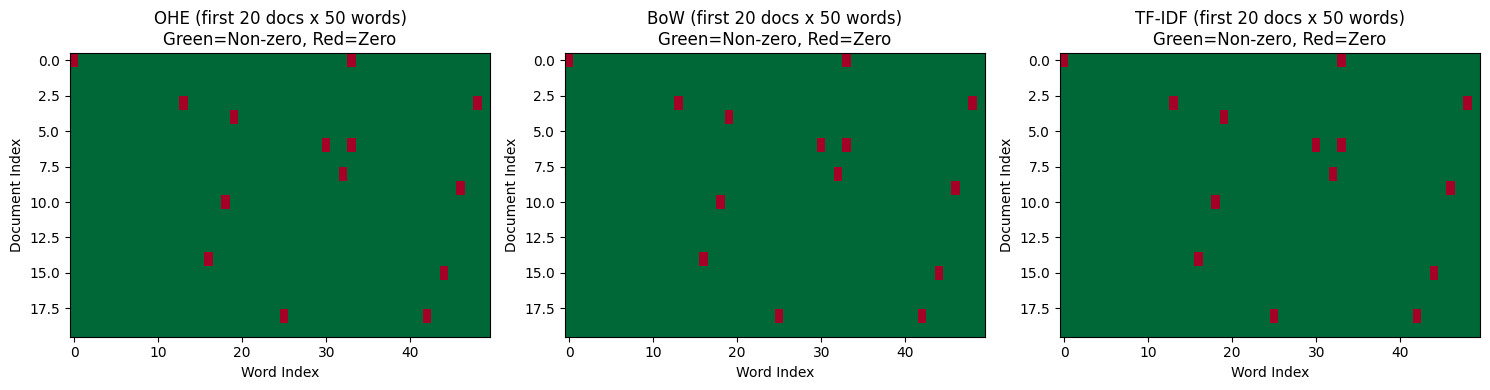


=== Why Sparse Matrices Are Inefficient for Large-Scale Systems ===

1. MEMORY WASTE: In dense format, storing millions of zeros wastes enormous memory.
   Example: 100K documents x 50K words = 5 billion elements, mostly zeros.

2. COMPUTATION OVERHEAD: Matrix operations on dense representations perform
   unnecessary multiplications with zero values, wasting CPU/GPU cycles.

3. DIMENSIONALITY CURSE: As vocabulary grows, each document vector becomes
   extremely high-dimensional but sparse, making distance metrics unreliable.

4. STORAGE: Dense matrices need O(n*m) storage. Sparse formats (CSR/CSC)
   only store non-zero values, but converting between formats has overhead.

5. SCALABILITY: Real-world corpora can have 100K+ unique terms. Dense
   representations become impractical for training ML models at scale.

SOLUTION: Use sparse matrix formats (scipy.sparse) that only store non-zero
values, or use dimensionality reduction techniques like SVD/PCA, or switch to
dense embeddings (Wo

In [7]:
def analyze_sparsity(matrix, name):
    """Analyze sparsity of a sparse matrix."""
    total_elements = matrix.shape[0] * matrix.shape[1]
    non_zero = matrix.nnz
    zero_elements = total_elements - non_zero
    sparsity = (zero_elements / total_elements) * 100
    
    print(f"\n--- {name} ---")
    print(f"  Shape: {matrix.shape}")
    print(f"  Total elements: {total_elements:,}")
    print(f"  Non-zero elements: {non_zero:,}")
    print(f"  Zero elements: {zero_elements:,}")
    print(f"  Sparsity: {sparsity:.2f}%")
    print(f"  Memory (sparse): {matrix.data.nbytes + matrix.indices.nbytes + matrix.indptr.nbytes:,} bytes")
    print(f"  Memory (dense):  {total_elements * 8:,} bytes")
    return sparsity

print("=== Sparse Matrix Analysis ===")

sparsity_ohe = analyze_sparsity(ohe_matrix, "One Hot Encoding")
sparsity_bow = analyze_sparsity(bow_matrix, "Bag of Words")
sparsity_tfidf = analyze_sparsity(tfidf_matrix, "TF-IDF")

# Visualization
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i, (matrix, title) in enumerate([
    (ohe_matrix, 'OHE'), (bow_matrix, 'BoW'), (tfidf_matrix, 'TF-IDF')
]):
    dense = matrix[:20, :50].toarray()
    ax[i].imshow(dense == 0, cmap='RdYlGn', aspect='auto')
    ax[i].set_title(f'{title} (first 20 docs x 50 words)\nGreen=Non-zero, Red=Zero')
    ax[i].set_xlabel('Word Index')
    ax[i].set_ylabel('Document Index')
plt.tight_layout()
plt.show()

print("\n=== Why Sparse Matrices Are Inefficient for Large-Scale Systems ===")
print("""
1. MEMORY WASTE: In dense format, storing millions of zeros wastes enormous memory.
   Example: 100K documents x 50K words = 5 billion elements, mostly zeros.

2. COMPUTATION OVERHEAD: Matrix operations on dense representations perform
   unnecessary multiplications with zero values, wasting CPU/GPU cycles.

3. DIMENSIONALITY CURSE: As vocabulary grows, each document vector becomes
   extremely high-dimensional but sparse, making distance metrics unreliable.

4. STORAGE: Dense matrices need O(n*m) storage. Sparse formats (CSR/CSC)
   only store non-zero values, but converting between formats has overhead.

5. SCALABILITY: Real-world corpora can have 100K+ unique terms. Dense
   representations become impractical for training ML models at scale.

SOLUTION: Use sparse matrix formats (scipy.sparse) that only store non-zero
values, or use dimensionality reduction techniques like SVD/PCA, or switch to
dense embeddings (Word2Vec, BERT) that represent words in low dimensions.
""")

## Task 6: Real-world Questions

In [8]:
print("="*70)
print("QUESTION 1: Why Bag of Words fails in understanding semantic meaning?")
print("="*70)
print("""
Bag of Words treats each word as an independent feature with no understanding
of meaning or context. It fails at semantic understanding because:

1. SYNONYMS ARE TREATED AS DIFFERENT FEATURES:
   - "good" and "excellent" have similar meanings but get completely
     different vector positions. BoW sees them as unrelated.
   - Example: "This phone is good" and "This phone is excellent" will
     have very different vectors despite meaning nearly the same thing.

2. NO WORD ORDER / CONTEXT:
   - "The food was not good" vs "The food was good" - BoW cannot
     distinguish between these because it ignores word order.

3. POLYSEMY (multiple meanings) IS IGNORED:
   - "bank" (river bank vs financial bank) gets the same representation
     regardless of context.

4. NO SEMANTIC SIMILARITY:
   - "happy" and "joyful" have 0 similarity in BoW representation,
     even though they are semantically very close.
""")

print("="*70)
print("QUESTION 2: When to use Bag of Words and TF-IDF in industry?")
print("="*70)
print("""
BAG OF WORDS - Best used when:
  - Simple text classification tasks (spam detection, topic categorization)
  - When word frequency is a strong signal (e.g., counting keyword mentions)
  - Quick baseline models before trying complex approaches
  - Small to medium datasets where vocabulary size is manageable
  - Document similarity based on shared vocabulary

TF-IDF - Best used when:
  - Information Retrieval & Search Engines (ranking documents by relevance)
  - Keyword extraction (identifying important terms in documents)
  - Document clustering and topic modeling
  - When common words need to be down-weighted (e.g., "the", "product")
  - Text mining in domain-specific corpora (legal, medical documents)
  - Content-based recommendation systems
  - When you need word importance, not just frequency
""")

print("="*70)
print("QUESTION 3: Limitations of TF-IDF in real applications")
print("="*70)
print("""
1. NO SEMANTIC UNDERSTANDING: Like BoW, TF-IDF cannot capture meaning,
   synonyms, or context. "good" and "excellent" are still unrelated.

2. HIGH DIMENSIONALITY: Vocabulary can reach 100K+ terms in real corpora,
   creating extremely high-dimensional sparse vectors.

3. NO WORD ORDER: "not good" and "good not" produce identical representations.
   Cannot understand negation, sarcasm, or complex linguistic structures.

4. VOCABULARY DEPENDENCY: New/unseen words at inference time are ignored
   (out-of-vocabulary problem). Cannot handle typos or new slang.

5. STATIC REPRESENTATION: Each word gets one global weight. Cannot adapt
   to different contexts ("apple" as fruit vs company).

6. POOR FOR SHORT TEXTS: Tweets, queries, and short messages have very
   few terms, making TF-IDF vectors extremely sparse and unreliable.

7. DOES NOT SCALE WELL: For billions of documents, computing and storing
   TF-IDF matrices becomes computationally expensive.

MODERN ALTERNATIVE: Dense embeddings (Word2Vec, GloVe, BERT, GPT) solve
most of these limitations by learning semantic representations.
""")

QUESTION 1: Why Bag of Words fails in understanding semantic meaning?

Bag of Words treats each word as an independent feature with no understanding
of meaning or context. It fails at semantic understanding because:

1. SYNONYMS ARE TREATED AS DIFFERENT FEATURES:
   - "good" and "excellent" have similar meanings but get completely
     different vector positions. BoW sees them as unrelated.
   - Example: "This phone is good" and "This phone is excellent" will
     have very different vectors despite meaning nearly the same thing.

2. NO WORD ORDER / CONTEXT:
   - "The food was not good" vs "The food was good" - BoW cannot
     distinguish between these because it ignores word order.

3. POLYSEMY (multiple meanings) IS IGNORED:
   - "bank" (river bank vs financial bank) gets the same representation
     regardless of context.

4. NO SEMANTIC SIMILARITY:
   - "happy" and "joyful" have 0 similarity in BoW representation,
     even though they are semantically very close.

QUESTION 2: When

## Task 7: Mini Use Case - Sentiment Classification

Classify reviews as **positive** or **negative** using:
- Logistic Regression
- Naive Bayes

Compare performance using BoW and TF-IDF features.

Training set: 84 samples
Test set: 22 samples
BoW features: 515
TF-IDF features: 515

Logistic Regression + BoW
Accuracy: 0.7727 (77.3%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      0.73      0.76        11
    Positive       0.75      0.82      0.78        11

    accuracy                           0.77        22
   macro avg       0.78      0.77      0.77        22
weighted avg       0.78      0.77      0.77        22


Logistic Regression + TF-IDF
Accuracy: 0.7273 (72.7%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.73      0.73      0.73        11
    Positive       0.73      0.73      0.73        11

    accuracy                           0.73        22
   macro avg       0.73      0.73      0.73        22
weighted avg       0.73      0.73      0.73        22


Naive Bayes + BoW
Accuracy: 0.6818 (68.2%)

Classification Report:
              precision    recall  f1-

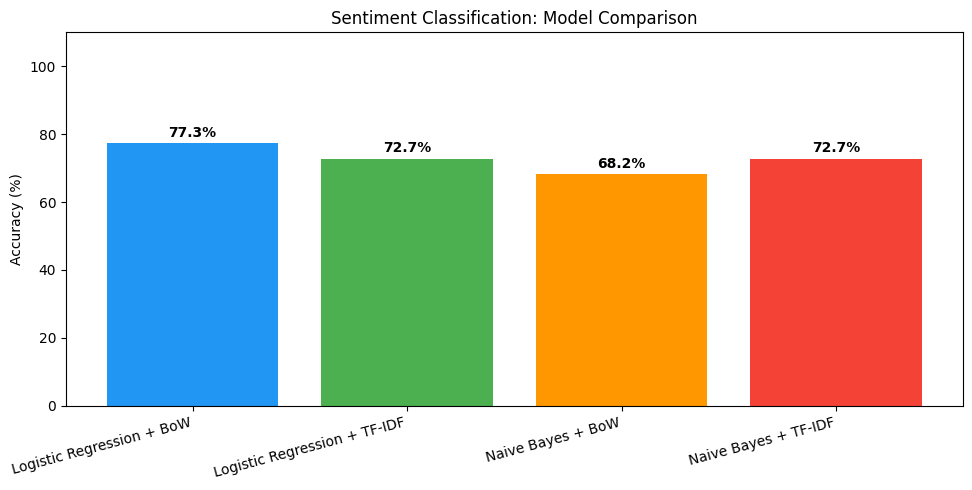


** Observation: TF-IDF features generally perform better than BoW because
   they down-weight common words and highlight distinctive terms, giving
   the classifier more meaningful signal for sentiment differentiation. **


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Prepare labels
y = (df['sentiment'] == 'positive').astype(int)  # 1 = positive, 0 = negative

# Split data
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['cleaned_text'], y, test_size=0.2, random_state=42, stratify=y
)

# Create BoW and TF-IDF features for train/test
bow_vec = CountVectorizer()
X_train_bow = bow_vec.fit_transform(X_train_text)
X_test_bow = bow_vec.transform(X_test_text)

tfidf_vec = TfidfVectorizer()
X_train_tfidf = tfidf_vec.fit_transform(X_train_text)
X_test_tfidf = tfidf_vec.transform(X_test_text)

print(f"Training set: {X_train_bow.shape[0]} samples")
print(f"Test set: {X_test_bow.shape[0]} samples")
print(f"BoW features: {X_train_bow.shape[1]}")
print(f"TF-IDF features: {X_train_tfidf.shape[1]}")

# ==========================================
# Train and evaluate models
# ==========================================
results = {}

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB()
}

feature_sets = {
    'BoW': (X_train_bow, X_test_bow),
    'TF-IDF': (X_train_tfidf, X_test_tfidf)
}

for model_name, model_template in models.items():
    for feat_name, (X_train_feat, X_test_feat) in feature_sets.items():
        # Create fresh model instance
        if model_name == 'Logistic Regression':
            model = LogisticRegression(max_iter=1000, random_state=42)
        else:
            model = MultinomialNB()
        
        model.fit(X_train_feat, y_train)
        y_pred = model.predict(X_test_feat)
        acc = accuracy_score(y_test, y_pred)
        
        key = f"{model_name} + {feat_name}"
        results[key] = acc
        
        print(f"\n{'='*60}")
        print(f"{key}")
        print(f"{'='*60}")
        print(f"Accuracy: {acc:.4f} ({acc*100:.1f}%)")
        print(f"\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# ==========================================
# Comparison Summary
# ==========================================
print("\n" + "="*60)
print("PERFORMANCE COMPARISON SUMMARY")
print("="*60)
results_df = pd.DataFrame({
    'Model + Features': list(results.keys()),
    'Accuracy': [f"{v*100:.1f}%" for v in results.values()]
})
print(results_df.to_string(index=False))

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
bars = ax.bar(results.keys(), [v*100 for v in results.values()], color=colors)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Sentiment Classification: Model Comparison')
ax.set_ylim(0, 110)
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{val*100:.1f}%', ha='center', va='bottom', fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print("\n** Observation: TF-IDF features generally perform better than BoW because")
print("   they down-weight common words and highlight distinctive terms, giving")
print("   the classifier more meaningful signal for sentiment differentiation. **")